In [1]:
import matplotlib.pyplot as plt
from scipy.signal import lfilter
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
from scipy import signal
def signalEnhancedData(N, L, sigma_nr2=10.0,):
    """
    Generate one realization for signal enhancement problem

    Returns:
        u : adaptive input (delayed reference)
        d : desired signal
        x_clean : ground truth clean signal (for evaluation)
    """

    # noise
    nr = np.sqrt(sigma_nr2) * np.random.randn(N)

    # clean signal
    x_clean = np.sin(0.2 * np.pi * np.arange(N))

    # reference
    r = x_clean + nr

    # delay (adaptive input)
    u = np.roll(r, L)
    u[:L] = 0

    # H(z)
    b = [0.4]
    a = [1, -1.36, 0.79]

    # filtered noise
    n1 = lfilter(b, a, nr)

    # desired signal
    d = x_clean + n1

    return u, d, x_clean

In [3]:
def runSigEnhanced(
    model,
    N=2000,
    L=10,
    sigma_nr2=10.0,
    n_runs=100,
    burnin=500,
):
    """
    Monte-Carlo signal enhancement experiment

    Returns:
        mse_avg : averaged learning curve
        misadj  : steady-state misadjustment (vs noise floor)
    """

    # determine output length
    u_test, d_test, x_test = signalEnhancedData(N, L, sigma_nr2)

    model.w = np.zeros_like(model.w)
    _, e_test, _ = model(u_test, d_test, train=False)
    out_len = len(e_test)

    mse_runs = np.zeros((n_runs, out_len))

    for r in range(n_runs):
        u, d, x_clean = signalEnhancedData(N, L, sigma_nr2)

        model.w = np.zeros_like(model.w)

        y, e, _ = model(u, d, train=True)

        mse_runs[r] = (e - x_clean[:out_len])**2

    mse_avg = np.mean(mse_runs, axis=0)

    burn = min(burnin, out_len // 2)

    # residual error
    misadj = np.mean(mse_avg[burn:])

    return mse_avg, misadj

/tmp/ipykernel_835/1091010297.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  mse_runs[r] = (e - x_clean[:out_len])**2


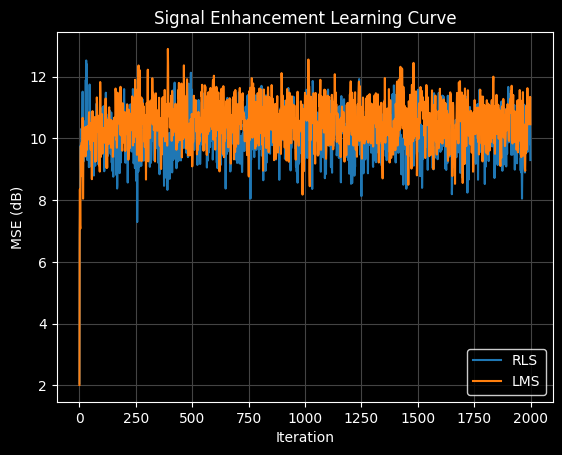

RLS residual: 10.430840220218057
LMS residual: 11.47324194831762


In [7]:
# RLS
M = 20
rls_model = adspfilter.RLS(mu=None, lam=0.99, delta=1e-2, filter_order=M-1)
mse_rls, M_rls = runSigEnhanced(rls_model)

# LMS
lms_model = adspfilter.LMS(mu=0.001, filter_order=M-1)
mse_lms, M_lms = runSigEnhanced(lms_model)

# plot
plt.figure()
plt.plot(10*np.log10(mse_rls), label="RLS")
plt.plot(10*np.log10(mse_lms), label="LMS")
plt.title("Signal Enhancement Learning Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.legend()
plt.grid()
plt.show()

print("RLS residual:", M_rls)
print("LMS residual:", M_lms)